In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
REPO_URL = 'https://github.com/LuisBetancourt11/Proyecto_Ciencia_Datos.git'
REPO_DIR = 'Proyecto_Ciencia_Datos'

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("El repositorio ya está clonado; actualizando con git pull...")
    !cd {REPO_DIR} && git pull

El repositorio ya está clonado; actualizando con git pull...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 5 (delta 0), reused 5 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 324.08 KiB | 7.54 MiB/s, done.
From https://github.com/LuisBetancourt11/Proyecto_Ciencia_Datos
   73d24b0..aa6d65f  main       -> origin/main
Updating 73d24b0..aa6d65f
Fast-forward
 data/processed/matriculas_limpias.csv | 13398 ++++++++++++++++++++++++++++++++
 1 file changed, 13398 insertions(+)
 create mode 100644 data/processed/matriculas_limpias.csv


In [3]:
processed_dir = REPO_DIR + '/data/processed/'

print("processed_dir:", processed_dir)
print("¿Existe el CSV limpio?:", os.path.exists(processed_dir + 'matriculas_limpias.csv'))

processed_dir: Proyecto_Ciencia_Datos/data/processed/
¿Existe el CSV limpio?: True


In [9]:
processed_dir = REPO_DIR + '/data/processed/'
df = pd.read_csv(processed_dir + 'matriculas_limpias.csv',
                 parse_dates=['fecha_de_matricula'])

# Subconjunto con etiqueta válida
d = df.dropna(subset=['desercion']).copy()

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (13397, 24)


,genero,municipio_de_nacimiento,pais,municipio_direccion,barrio_direccion,estrato,estado_civil,eps,grupo_sisben,zona,...,estado,fecha_de_matricula,jornada,programa,periodo,nivel,edad,anio_matricula,mes_matricula,desercion
0,Femenino,Medellín,Colombia,Envigado,Las Flores,3.0,Soltero(a),EPS Sura,NaN,Urbana,...,Graduado,2018-02-05 10:00:00+00:00,MEDIA TÉCNICA,MEDIA TÉCNICA TECNICO LABORAL AUXILIAR ADMINIS...,2018-2,SEMESTRE 2,20.0,2018.0,2.0,0.0
1,Femenino,Envigado,Colombia,Envigado,San José,2.0,Soltero(a),EPS Sura,NaN,Urbana,...,Graduado,2016-01-19 10:00:00+00:00,NOCHE,10T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO...,2016-2,SEMESTRE 2,29.0,2016.0,1.0,0.0
2,Masculino,Bogotá,Colombia,La Mesa,NaN,3.0,Soltero(a),NaN,NaN,Rural,...,Cancelado,2021-02-08 10:00:00+00:00,NOCHE,09T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,2021-2,SEMESTRE 1,19.0,2021.0,2.0,1.0
3,Masculino,Envigado,Colombia,Envigado,San José,2.0,Soltero(a),SISBEN,B3,Urbana,...,Graduado,2020-01-17 10:00:00+00:00,DIURNA,01T-TÉCNICO LABORAL AUXILIAR DE TALENTO HUMANO,2021-1,SEMESTRE 2,21.0,2020.0,1.0,0.0
4,Masculino,Medellín,Colombia,Envigado,El Salado,2.0,Soltero(a),Nueva Promotora de Salud - Nueva EPS,N0,Urbana,...,Inactivo,2020-01-27 10:00:00+00:00,NOCHE,27T-TÉCNICO LABORAL EN MERCADEO Y VENTAS (Estu...,2020-1,SEMESTRE 1,20.0,2020.0,1.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13397 entries, 0 to 13396
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   genero                   13397 non-null  object             
 1   municipio_de_nacimiento  12269 non-null  object             
 2   pais                     13346 non-null  object             
 3   municipio_direccion      13344 non-null  object             
 4   barrio_direccion         12079 non-null  object             
 5   estrato                  12187 non-null  float64            
 6   estado_civil             11961 non-null  object             
 7   eps                      10367 non-null  object             
 8   grupo_sisben             3112 non-null   object             
 9   zona                     12128 non-null  object             
 10  nivel_de_formacion       10062 non-null  object             
 11  ocupacion                114

In [6]:
# Resumen estadístico de las variables numéricas
df.describe()

,estrato,edad,anio_matricula,mes_matricula,desercion
count,12187.000000,13396.000000,12186.000000,12186.000000,13158.000000
mean,2.572085,28.263735,2018.207451,5.331610,0.474008
std,0.732217,14.195340,2.252825,3.415874,0.499343
min,0.000000,-973.000000,1988.000000,1.000000,0.000000
25%,2.000000,20.000000,2016.000000,2.000000,0.000000
50%,3.000000,26.000000,2018.000000,6.000000,0.000000
75%,3.000000,34.000000,2020.000000,7.000000,1.000000
max,6.000000,79.000000,2022.000000,12.000000,1.000000


#**Pregunta 1:**
¿Cómo está distribuida la variable objetivo `desercion`?
¿El problema está balanceado?

In [7]:
# Tabla: conteo de cada clase (incluye los 'Sin estado' que quedaron como NaN)
conteo = df['desercion'].value_counts(dropna=False)
print(conteo)
print()
print("Proporción (sobre los etiquetados):")
print(df['desercion'].value_counts(normalize=True).round(3))

desercion
0.0    6921
1.0    6237
NaN     239
Name: count, dtype: int64

Proporción (sobre los etiquetados):
desercion
0.0    0.526
1.0    0.474
Name: proportion, dtype: float64


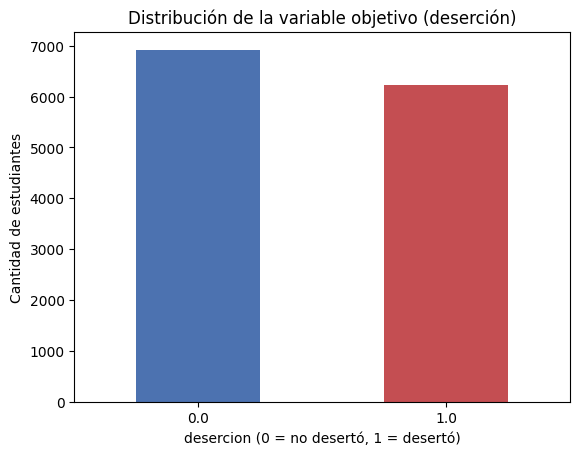

In [8]:
# Gráfico
df['desercion'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Distribución de la variable objetivo (deserción)')
plt.xlabel('desercion (0 = no desertó, 1 = desertó)')
plt.ylabel('Cantidad de estudiantes')
plt.xticks(rotation=0)
plt.show()

**Respuesta:** Hay **6.921 no desertores (0)** y **6.237 desertores (1)**, más **239
sin etiqueta**. Eso da una tasa global de deserción de **~47%**.

**Conclusión:** La tasa de deserción está **casi balanceado (47/53)**, lo cual es ideal. Las 239 filas sin etiqueta deben **excluirse** antes
de entrenar.

#**Pregunta 2:**
¿Qué columnas tienen más valores faltantes?

multiculturalidad      93.8
grupo_sisben           76.8
nivel_de_formacion     24.9
medio_de_transporte    24.7
eps                    22.6
ocupacion              14.2
estado_civil           10.7
barrio_direccion        9.8
zona                    9.5
anio_matricula          9.0
dtype: float64


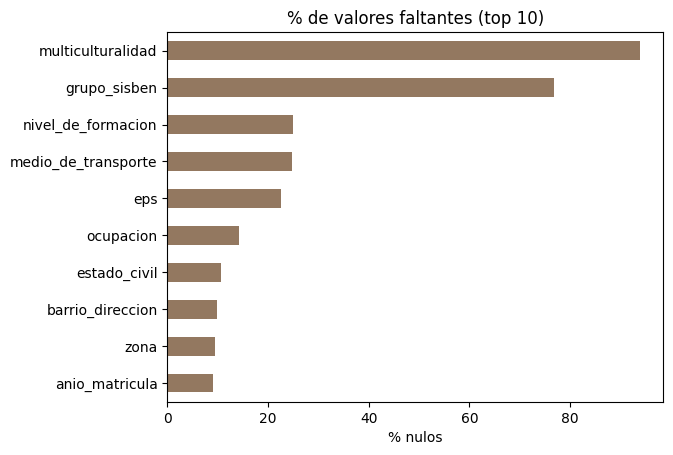

In [10]:
nulos = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
print(nulos.head(10))

nulos.head(10).plot(kind='barh', color='#937860')
plt.title('% de valores faltantes (top 10)')
plt.xlabel('% nulos'); plt.gca().invert_yaxis(); plt.show()

**Respuesta:** Las más incompletas son **`multiculturalidad` (93,8%)** y
**`grupo_sisben` (76,8%)**, prácticamente vacías. Les siguen `nivel_de_formacion` (24,9%),
`medio_de_transporte` (24,7%) y `eps` (22,6%).

**Conclusión:** `multiculturalidad` y `grupo_sisben` casi no aportan información por sí
solas. Una opción es **descartarlas**, o convertir `grupo_sisben` en una variable binaria
"tiene/no tiene registro". Las que tengan un porcentaje al >= a 20% se evaluara una manera de normalizarlas si es necesario.

#**Pregunta 3:**
Una vez filtradas las anomalías, ¿cómo se distribuye la edad?

In [12]:
print(df['edad'].describe())
print()
print("Edades menores a 10 años:", (df['edad'] < 10).sum())
print("Edad mínima registrada:", df['edad'].min())

count    13396.000000
mean        28.263735
std         14.195340
min       -973.000000
25%         20.000000
50%         26.000000
75%         34.000000
max         79.000000
Name: edad, dtype: float64

Edades menores a 10 años: 93
Edad mínima registrada: -973.0


count    13303.0
mean        28.5
std         11.1
min         12.0
25%         20.0
50%         26.0
75%         34.0
max         79.0
Name: edad, dtype: float64


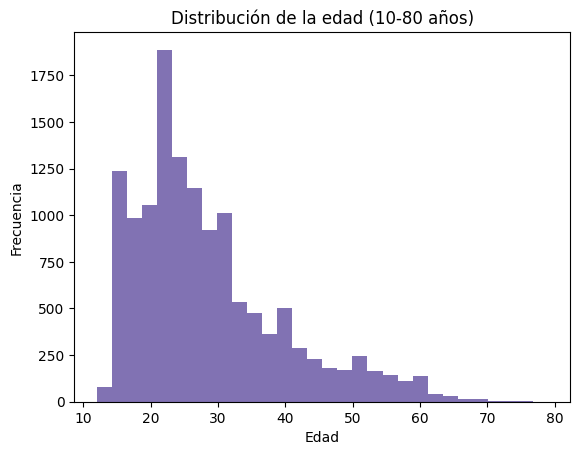

In [13]:
edad_ok = df[(df['edad'] >= 10) & (df['edad'] <= 80)]
print(edad_ok['edad'].describe().round(1))

edad_ok['edad'].plot(kind='hist', bins=30, color='#8172B3')
plt.title('Distribución de la edad (10-80 años)')
plt.xlabel('Edad'); plt.ylabel('Frecuencia'); plt.show()

**Respuesta:** La distribución está **sesgada a la derecha**: la mayoría tiene entre
**20 y 34 años** (mediana ≈ 26), con una cola de estudiantes mayores.

**Conclusión:** Es una población joven-adulta. La edad puede ser un predictor útil. Hay alguans edades que no son posibles, por lo tanto se discriminan

#**Pregunta 4:**
 ¿La deserción difiere entre géneros?

            mean  count
genero                 
Masculino  0.524   6985
Femenino   0.417   6172


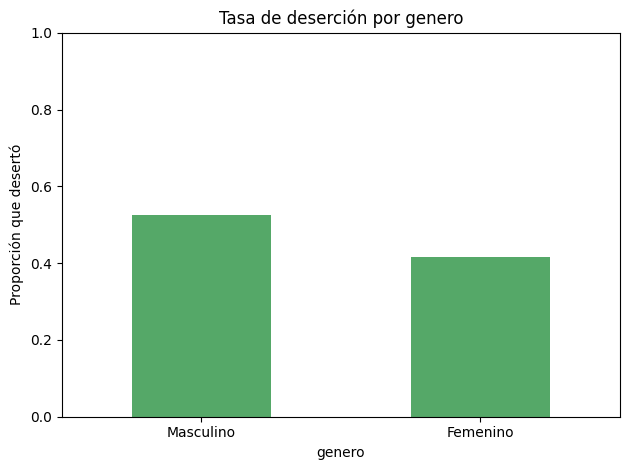

In [14]:
g = d.groupby('genero')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#55A868')
plt.title('Tasa de deserción por genero')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=0, ha='right' if 0 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** Los **hombres desertan más (52,4%)** que las mujeres (**41,7%**): ~11 puntos de diferencia, esto indica que los hombres tienen una tasa de deserción mayor a las mujeres.

**Conclusión:** `genero` es un predictor con señal real.

# **Pregunta 5:**
¿La tasa de deserción cambia según el estrato socioeconómico?

          mean  count
estrato              
5.0      0.581    136
1.0      0.522    383
3.0      0.501   5499
4.0      0.499    651
2.0      0.475   5234


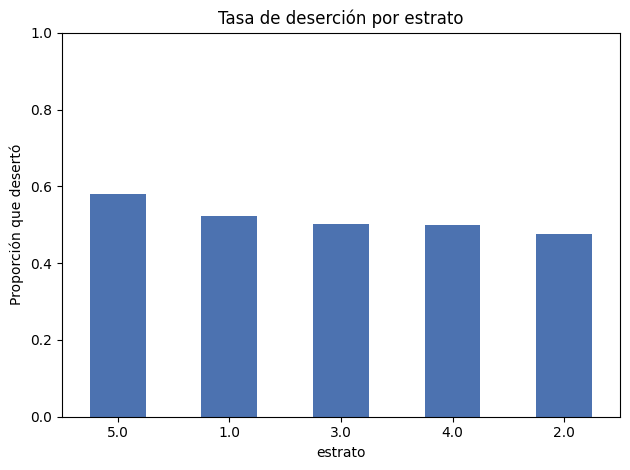

In [28]:
g = d.groupby('estrato')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 45].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#4C72B0')
plt.title('Tasa de deserción por estrato')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=0, ha='right' if 0 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** La relación **no es monótona**: estratos 5 (58%), 1 (52%) y 3 (50%) están altos.

**Conclusión:** El estrato por sí solo **no separa bien** la deserción, su correlación con la tasa de deserción es casi nula.

#**Pregunta 6:**
¿Difiere la deserción entre zona urbana y rural?

                 mean  count
zona                        
Rural           0.524    811
Urbana - rural  0.514    428
Urbana          0.487  10673


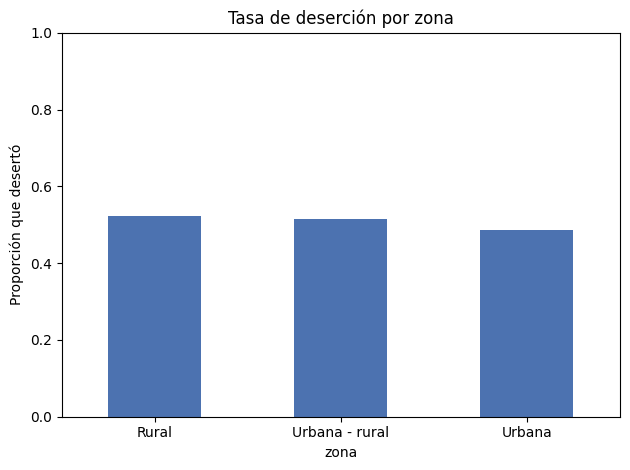

In [16]:
g = d.groupby('zona')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#4C72B0')
plt.title('Tasa de deserción por zona')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=0, ha='right' if 0 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** La zona **rural deserta algo más (52,4%)** que la urbana (48,7%); la mixta queda en medio (51%).

**Conclusión:** Hay una diferencia leve pero consistente, los estudiantes rurales son ligeramente más propensos a desertar, posiblemente por distancia o conectividad.

#**Pregunta 7:**
¿El estado civil se relaciona con la deserción?

                mean  count
estado_civil               
Soltero(a)     0.508   9582
Viudo(a)       0.487     39
Separado(a)    0.446    204
Casado(a)      0.390    925
Unión libre    0.376    935
Divorciado(a)  0.232     56


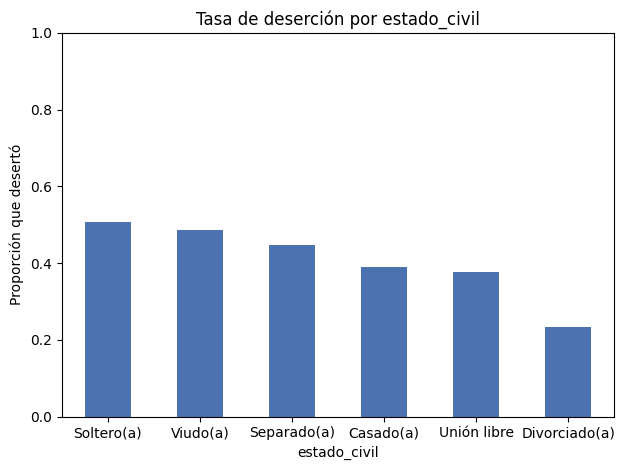

In [17]:
g = d.groupby('estado_civil')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#4C72B0')
plt.title('Tasa de deserción por estado_civil')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=0, ha='right' if 0 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** Los **solteros desertan más (50,8%)**. En cambio, quienes están en **unión libre (37,6%)**, **casados (39,0%)** o **divorciados (23,2%)** desertan menos.

**Conclusión:** Tener pareja/estabilidad familiar parece asociarse a **menor** deserción.

#**Pregunta 8:**
¿La edad se relaciona con desertar?

desercion
0.0    30.5
1.0    26.4
Name: edad, dtype: float64


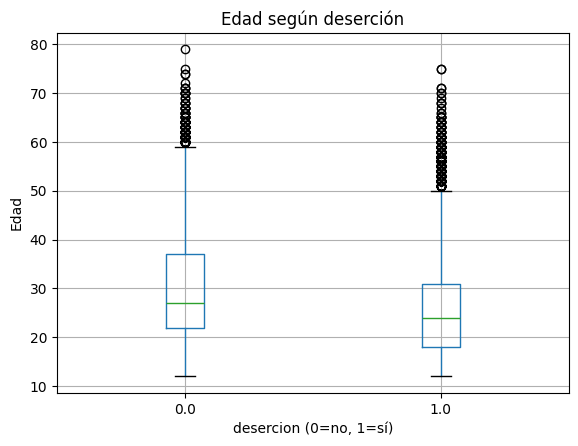

In [18]:
dd = d[(d['edad'] >= 10) & (d['edad'] <= 80)]
print(dd.groupby('desercion')['edad'].mean().round(1))

dd.boxplot(column='edad', by='desercion')
plt.title('Edad según deserción'); plt.suptitle('')
plt.xlabel('desercion (0=no, 1=sí)'); plt.ylabel('Edad'); plt.show()

**Respuesta:** Los **desertores son más jóvenes** (edad media **26,4**) que los no
desertores (**30,5**).

**Conclusión:** A menor edad, mayor probabilidad de desertar. Es la variable **numérica**
con mayor relación con la tasa de deserción.

# **Pregunta 9:**
¿Qué jornada concentra mayor deserción?

                mean  count
jornada                    
MEDIA TÉCNICA  0.742   2636
NOCHE          0.421   6202
DIURNA         0.369   4192


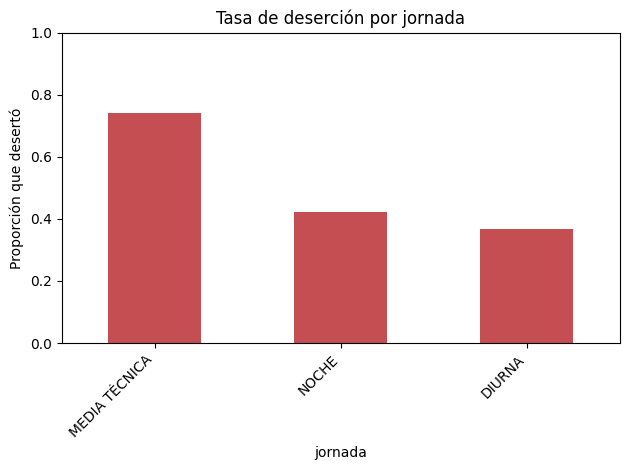

In [19]:
g = d.groupby('jornada')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#C44E52')
plt.title('Tasa de deserción por jornada')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right' if 45 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** La diferencia es **enorme**: **Media Técnica deserta 74,2%**, muy por encima de Noche (42,1%) y Diurna (36,9%).

**Conclusión:** La jornada es **uno de los predictores más fuertes** del dataset. Media Técnica (estudiantes de colegio en orientación vocacional) tiene un comportamiento muy distinto al resto y merece atención especial.

#**Pregunta 10:**
¿El nivel cursado (semestre/grado) se relaciona con la deserción?

             mean  count
nivel                   
NOVENO      0.884   1529
ONCE        0.622    492
DÉCIMO      0.551    517
SEMESTRE 1  0.519   4326
SEMESTRE 2  0.311   6164


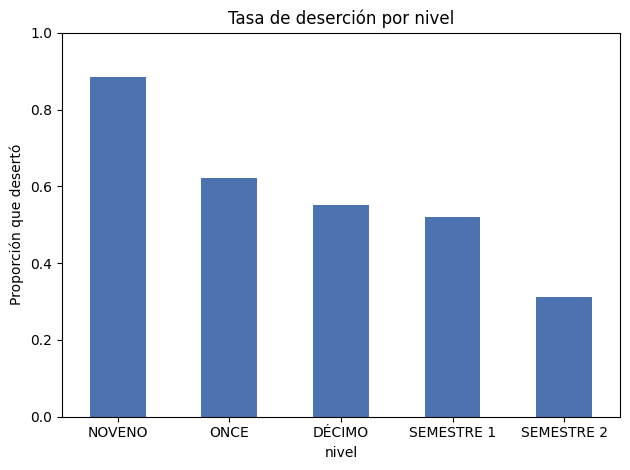

In [20]:
g = d.groupby('nivel')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#4C72B0')
plt.title('Tasa de deserción por nivel')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=0, ha='right' if 0 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** **Noveno grado dispara la deserción a 88,4%**, seguido de Once (62%) y Décimo (55%). En contraste, **Semestre 2 es el más bajo (31,1%)** y Semestre 1 queda en 51,9%.

**Conclusión:** El nivel es **muy predictivo**. Los grados de bachillerato (noveno-once) desertan muchísimo más que los semestres técnicos avanzados: quien llega a Semestre 2 ya 'sobrevivió' la etapa de mayor riesgo.

#**Pregunta 11:**
¿La ocupación del estudiante influye en la deserción?

                      mean  count
ocupacion                        
Estudiante básica    0.670   2292
Estudiante superior  0.487   3606
Independiente        0.400    982
Empleado             0.398   2706
Desempleado          0.384   1696


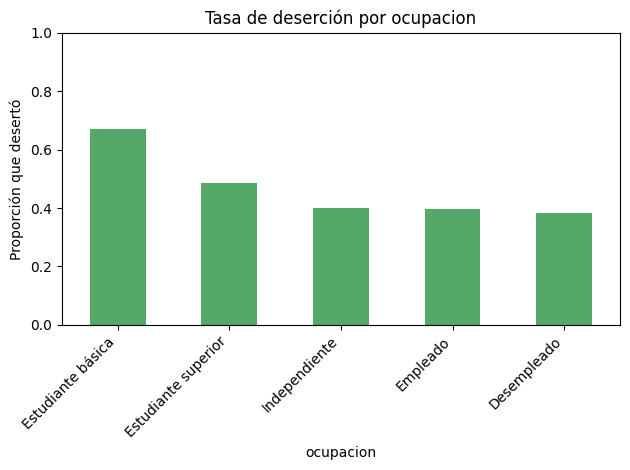

In [21]:
g = d.groupby('ocupacion')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#55A868')
plt.title('Tasa de deserción por ocupacion')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right' if 45 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** **'Estudiante básica' deserta más (67%)**; le sigue 'Estudiante superior' (49%). Quienes trabajan —empleados (39,8%), independientes (40%)— o están desempleados (38,4%) desertan menos.

**Conclusión:** Coherente con la edad y el nivel: los estudiantes más jóvenes (de básica) son los de mayor riesgo.

#**Pregunta 12**
¿Cuántos programas existen y cuáles concentran más matrículas?

Programas únicos: 78

programa
MEDIA TÉCNICA - ORIENTACIÓN VOCACIONAL                                                                1531
17T-TÉCNICO LABORAL EN ENTRENAMIENTO DEPORTIVO                                                        1027
10T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO CON ÉNFASIS EN SISTEMAS (Solo Estudiantes Antiguos)     909
26T-TÉCNICO LABORAL EN MECÁNICA DE MOTOS  (Estudiantes Antiguos)                                       709
01T-TÉCNICO LABORAL AUXILIAR DE TALENTO HUMANO                                                         626
24T-TÉCNICO LABORAL EN MECANICA AUTOMOTRIZ (Estudiantes Antiguos)                                      602
19T-TÉCNICO LABORAL EN GASTRONOMIA INTERNACIONAL                                                       598
11T-TÉCNICO LABORAL EN AUXILIAR CONTABLE (Solo Estudiantes Antiguos)                                   582
Name: count, dtype: int64


/tmp/ipykernel_4652/635401755.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.xlabel('Matrículas'); plt.tight_layout(); plt.show()


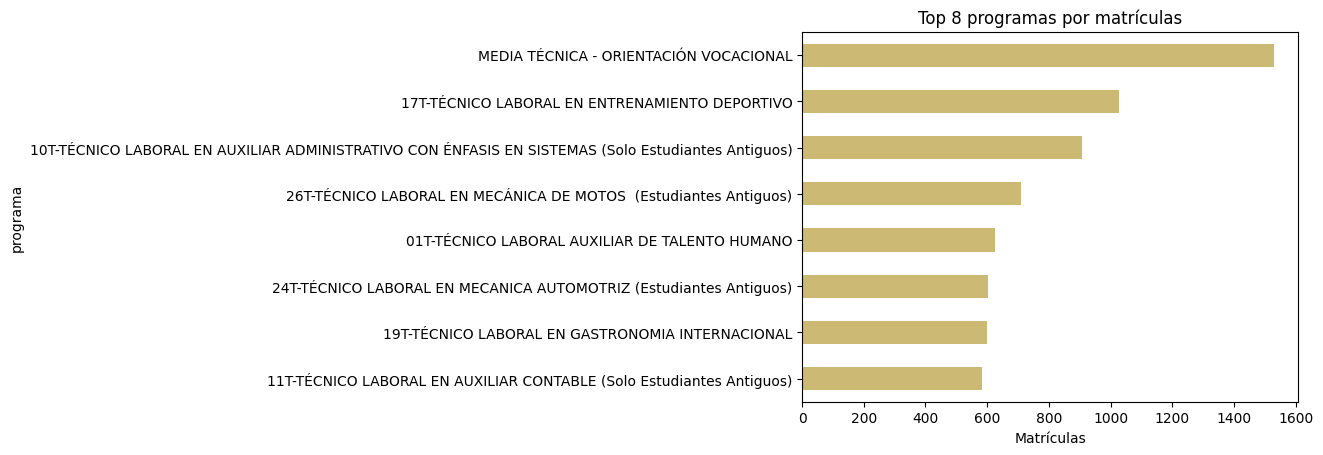

In [22]:
print("Programas únicos:", df['programa'].nunique())
print()
top = df['programa'].value_counts().head(8)
print(top)

top.sort_values().plot(kind='barh', color='#CCB974')
plt.title('Top 8 programas por matrículas')
plt.xlabel('Matrículas'); plt.tight_layout(); plt.show()

**Respuesta:** Hay **78 programas distintos**. El más numeroso es **Media Técnica –
Orientación Vocacional (1.531)**, seguido de Técnico en Entrenamiento Deportivo (1.027) y
varios técnicos laborales (auxiliar administrativo, mecánica de motos, talento humano…).

**Conclusión:** Se visualiza que los mayores programdas acádemicos cursados son: MEDIA TÉCNICA - ORIENTACIÓN VOCACIONAL y TÉCNICO LABORAL EN ENTRENAMIENTO DEPORTIVO.

# **Pregunta 13:**
¿El medio de transporte se relaciona con la deserción?

                         mean  count
medio_de_transporte                 
Carro Particular        0.593    123
Particular Automóvil    0.573    253
Público Taxi            0.507     71
Bicicleta               0.492    191
Particular Bicicleta    0.487     78
A Pie                   0.486   2378
Público Bus o Buseta    0.459   4386
Otro                    0.457     94
SITP o Bus              0.441     59
Peatón                  0.431    629
Público Metro           0.429    247
Público Otro            0.412    131
Particular Otro         0.412     34
Moto                    0.397    806
Particular Motocicleta  0.368    418


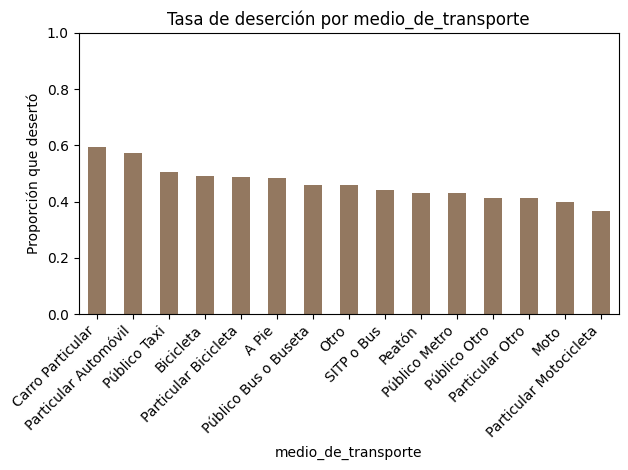

In [25]:
g = d.groupby('medio_de_transporte')['desercion'].agg(['mean', 'count'])
g = g[g['count'] >= 30].sort_values('mean', ascending=False)
print(g.round(3))

g['mean'].plot(kind='bar', color='#937860')
plt.title('Tasa de deserción por medio_de_transporte')
plt.ylabel('Proporción que desertó'); plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right' if 45 else 'center')
plt.tight_layout(); plt.show()

**Respuesta:** Quienes usan **carro/automóvil particular desertan más (57-59%)**, mientras que quienes se mueven en **moto/motocicleta desertan menos (37-40%)**. El bus público y caminar quedan alrededor del promedio (~46-49%).

**Conclusión:** La relación existe pero es difícil de interpretar de forma causal, ya que se evidencia que las personas con carro particular y automovil se puede considerar como una sola variable.

# **Pregunta 14:**
¿Cómo ha evolucionado la deserción según el año de matrícula?

                 mean  count
anio_matricula              
2014.0          0.550    349
2015.0          0.503   1339
2016.0          0.512   2033
2017.0          0.442   1203
2018.0          0.472   1406
2019.0          0.508   1204
2020.0          0.608   2426
2021.0          0.538   1716
2022.0          0.008    509


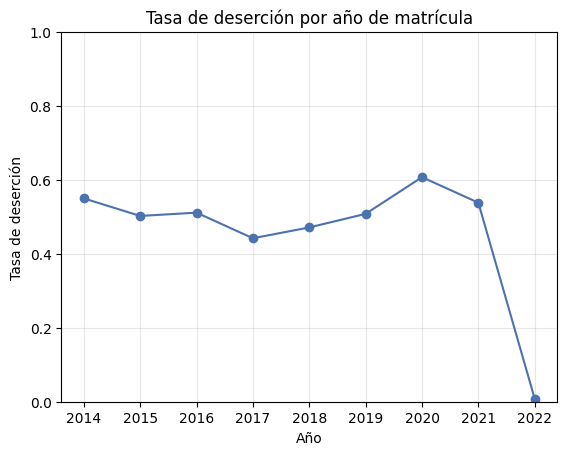

In [26]:
g = d[d['anio_matricula'] >= 2014].groupby('anio_matricula')['desercion'].agg(['mean','count'])
print(g.round(3))

g['mean'].plot(kind='line', marker='o', color='#4C72B0')
plt.title('Tasa de deserción por año de matrícula')
plt.xlabel('Año'); plt.ylabel('Tasa de deserción'); plt.ylim(0,1)
plt.grid(alpha=0.3); plt.show()

**Respuesta:** La deserción se mantiene entre 44% y 51% casi todos los años, con un
**pico en 2020 (60,8%)**  coincidiendo con la pandemia.

**Conclusión:** El 2022 no significa que "dejaran de desertar" son **cohortes recientes que
todavía siguen activas** y aún no han tenido tiempo de desertar censura temporal. Es una señal de **fuga de información temporal** hay que tener cuidado
al usar `anio_matricula` o decidir un punto de corte, para no entrenar el modelo con
desenlaces aún incompletos.

#**Pregunta 15:**
¿De dónde provienen los estudiantes?

municipio_de_nacimiento
Medellín     4530
Envigado     3578
Itagui       1199
Bogotá        189
Bello         156
Venezuela      85
Name: count, dtype: int64


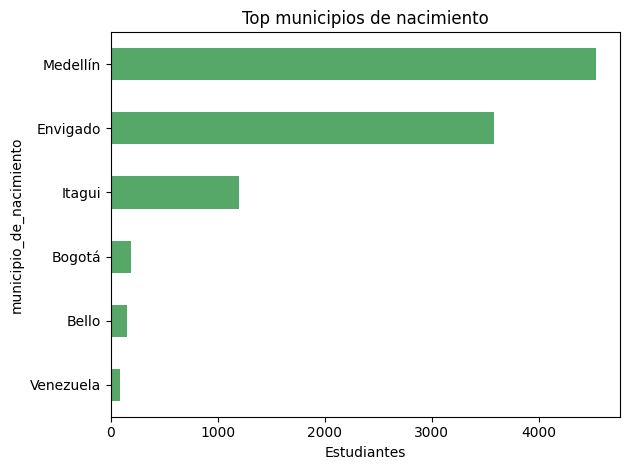

In [27]:
top_mun = df['municipio_de_nacimiento'].value_counts().head(6)
print(top_mun)

top_mun.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top municipios de nacimiento')
plt.xlabel('Estudiantes'); plt.tight_layout(); plt.show()

**Respuesta:** Predomina el **Área Metropolitana de Medellín**: Medellín (4.530),
Envigado (3.578) e Itagüí (1.199) concentran la gran mayoría. Bogotá y Bello aparecen
mucho más abajo.

**Conclusión:** La población es **geográficamente concentrada**, así que `municipio` o
`pais` (99,6% Colombia) aportan poca varianza. Probablemente se puedan simplificar o
descartar como predictores.